Copyright 2024 Google LLC. Licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

# Forecasting county-level unemployment rates using TimesFM and PDFM embeddings.

Note: This notebook demonstrates a highly experimental approach for forecasting county-level unemployment rates using TimesFM and PDFM embeddings. The methods and models applied here are in the early stages of development and may not yet provide reliable, production-grade forecasts. Results should be interpreted with caution, and further validation and tuning are recommended before applying these models in real-world scenarios.

# Data Preparation

#### Step 1: To download a csv file of the embeddings, please request via email to pdfm-embeddings@google.com with the subject line 'Access to PDFM Embeddings' and a description of the usecase. Once the file is downloaded, follow the rest of the steps in this notebook.

The county and ZCTA (zipcode census tabulation area) embeddings are available in different files.

Here we assume that you have obtained the embeddings and uploaded them to a Google Drive directory called `pdfm_embeddings/v0/us`.

In [2]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
PROJECT_ID = 'pdfm-ttp-504664' # @param {type:"string"}

In [4]:
import pandas as pd
import pandas_gbq


# @markdown Specify the BigQuery table ID for the county embeddings.
# Example: 'your-gcp-project.your_dataset.your_table'
bigquery_table_id = 'pdfm-ttp-504664.pdfm_embeddings.us_embeddings_v0' # @param {type:"string"}

query = f"SELECT * FROM `{bigquery_table_id}` WHERE region_type='county'"

# Load data from BigQuery into a pandas DataFrame.
county_raw_embeddings = pandas_gbq.read_gbq(query, project_id=PROJECT_ID, dialect='standard').set_index('place_name')

Downloading: 100%|██████████|


In [5]:
embedding_features = [f'feature{x}' for x in range(330)]

## Extract metadata

Extract 'state', 'county', 'population', 'latitude', and 'longitude' from the 'location_metadata' column of `county_raw_embeddings`.


In [6]:
def extract_metadata(metadata_dict):
    """Extracts specified metadata fields from a dictionary, handling missing keys."""
    state = metadata_dict.get('administrative_area_level1')
    county = metadata_dict.get('administrative_area_level2')
    population = metadata_dict.get('population')
    latitude = metadata_dict.get('latitude')
    longitude = metadata_dict.get('longitude')
    return {
        'state': state,
        'county': county,
        'population': population,
        'latitude': latitude,
        'longitude': longitude,
    }

# Apply the extraction function and create a new DataFrame
county_metadata = county_raw_embeddings['location_metadata'].apply(extract_metadata).apply(pd.Series)

# Display the first few rows and information about the new DataFrame
display("Extracted County Metadata:")
display(county_metadata.head())

'Extracted County Metadata:'

,state,county,population,latitude,longitude
place_name,,,,,
geoId/01001,Alabama,Autauga County,58761,32.532237,-86.646439
geoId/01003,Alabama,Baldwin County,233420,30.659218,-87.746067
geoId/01005,Alabama,Barbour County,24877,31.870253,-85.405103
geoId/01007,Alabama,Bibb County,22251,33.015893,-87.127148
geoId/01009,Alabama,Blount County,59077,33.977357,-86.566440


In [7]:
expanded_features = pd.DataFrame(county_raw_embeddings['features'].tolist(), index=county_raw_embeddings.index)
expanded_features.columns = [f'feature{i}' for i in range(expanded_features.shape[1])]

# Combine the extracted metadata, expanded features, and region_type into the final county_embeddings DataFrame
county_embeddings = pd.concat(
    [county_metadata, expanded_features, county_raw_embeddings[['region_type']]], axis=1
)

# Display the first few rows and information about the final DataFrame
display("Final County Embeddings DataFrame:")
display(county_embeddings.head())

'Final County Embeddings DataFrame:'

,state,county,population,latitude,longitude,feature0,feature1,feature2,feature3,feature4,...,feature321,feature322,feature323,feature324,feature325,feature326,feature327,feature328,feature329,region_type
place_name,,,,,,,,,,,,,,,,,,,,,
geoId/01001,Alabama,Autauga County,58761,32.532237,-86.646439,-0.059204,1.153834,0.286746,0.324178,1.003599,...,-0.165617,0.816348,-0.167234,2.099072,-0.168644,1.155944,1.620912,-0.089127,4.831956,county
geoId/01003,Alabama,Baldwin County,233420,30.659218,-87.746067,-0.089298,0.710666,0.358453,1.138983,2.012795,...,0.049021,0.892724,-0.061048,2.791007,-0.166232,0.276117,2.892894,-0.128016,4.151655,county
geoId/01005,Alabama,Barbour County,24877,31.870253,-85.405103,-0.089458,1.756277,0.749515,0.796651,0.555815,...,-0.013691,0.346536,-0.106772,2.986117,-0.104402,-0.059600,1.893656,-0.147867,0.032731,county
geoId/01007,Alabama,Bibb County,22251,33.015893,-87.127148,-0.117877,0.725561,0.436291,0.307150,1.347822,...,-0.168179,1.796390,-0.128314,1.395750,-0.084409,3.489884,1.249768,-0.028330,4.688914,county
geoId/01009,Alabama,Blount County,59077,33.977357,-86.566440,-0.133150,0.648858,0.592053,0.382824,1.486730,...,0.689164,2.527887,-0.045288,0.530547,-0.156357,1.227069,1.439654,-0.045479,3.491446,county


#### Step 2: Download and prepare monthly unemployment data at county level from Data Commons

In [8]:
!pip install datacommons_pandas --upgrade --quiet
import datacommons_pandas as dc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.6 MB/s eta 0:00:00


In [9]:
label = 'UnemploymentRate_Person'
# Due to response size limits, we'll query in batches.
batch_size = 200

all_labels = []
for start in range(0, county_embeddings.index.shape[0], batch_size):
    batch_indices = county_embeddings.index[start : start + batch_size]
    batch_data = dc.build_time_series_dataframe(batch_indices, label)
    all_labels.append(batch_data)

df_labels = pd.concat(all_labels)
# Include only columns corresponding to monthly data by excluding yearly data columns
df_labels = df_labels.loc[:, df_labels.columns.str.contains('-')]
df_labels.dropna(inplace=True)

print(df_labels.shape)
df_labels.head(2)

(2881, 428)


,1990-01,1990-02,1990-03,1990-04,1990-05,1990-06,1990-07,1990-08,1990-09,1990-10,...,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08
place,,,,,,,,,,,,,,,,,,,,,
geoId/01001,6.5,6.4,5.6,6.6,6.1,7.2,6.0,6.8,7.3,7.3,...,2.9,2.8,3.0,3.0,2.9,2.3,2.4,2.6,2.4,2.2
geoId/01003,6.4,6.0,5.2,4.9,4.3,4.8,4.9,4.9,5.4,4.9,...,2.9,3.0,3.1,3.2,3.1,2.4,2.5,2.7,2.4,2.3


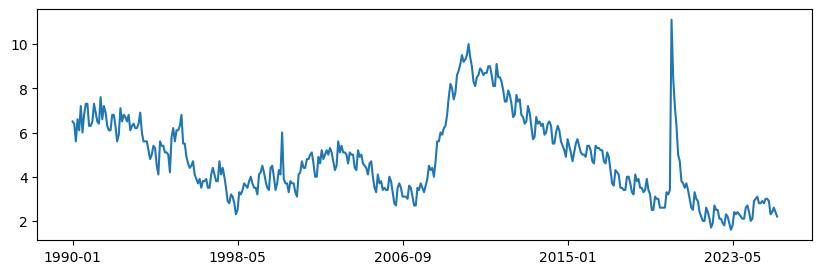

In [10]:
import matplotlib.dates as mdates
_ax = df_labels.loc['geoId/01001'].plot(figsize=(10, 3))

# Modeling



In [11]:
#@title Install TimesFM

!pip install git+https://github.com/google-research/timesfm.git

  Cloning https://github.com/google-research/timesfm.git to /tmp/pip-req-build-41ww18ht
  Running command git clone --filter=blob:none --quiet https://github.com/google-research/timesfm.git /tmp/pip-req-build-41ww18ht
  Resolved https://github.com/google-research/timesfm.git to commit bf88c5dc88f6275b7071ebcd9051406c11435c0c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 8.7 MB/s eta 0:00:00
  Created wheel for timesfm: filename=timesfm-2.0.0-py3-none-any.whl size=43795 sha256=843a284c4e251d697fa8a79c37275dd6ac950d92602060ff605e6f95b97d052c
  Stored in directory: /tmp/pip-ephem-wheel-cache-b7xn1nnk/wheels/d0/38/4b/2726a715c889b3debae031f66677e568b6cac46fdc9f1c63eb
Successfully built timesfm


In [12]:
#@title Initialize a TimesFM model
import timesfm

timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.


model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

In [13]:
#@title Define our forecasting model
import lightgbm as lgbm
import numpy as np

class PDTimesFM:
  """Forecasts time series data using TimesFM and PDFM embeddings for error correction.

  This class combines the strengths of TimesFM for base forecasting and PDFM
  embeddings
  for capturing spatial correlations to improve prediction accuracy.
  """

  def __init__(
      self, timesfm_model, pdfm_embeddings, error_correction_model=None
  ):
    """Initializes the PDTimesFM model with a TimesFM model for forecasting

    and PDFM embeddings for error correction.

    Args:
        timesfm_model: The TimesFM model to use for forecasting.
        pdfm_embeddings: A pandas DataFrame containing the PDFM embeddings.
        error_correction_model: An optional error correction model to use.
    """
    self.timesfm_model = timesfm_model
    self.pdfm_embeddings = pdfm_embeddings
    self.error_correction_model = error_correction_model or lgbm.LGBMRegressor(
        max_leaf_nodes=19,
        min_samples_leaf=5,
        learning_rate=0.05,
        n_estimators=400,
        feature_fraction=0.8,
        verbose=-1,
    )

  def get_timesfm_forecast(self, history, forecast_steps=24, batch_size=128):
    """Obtains TimesFM forecasts in batches to handle large datasets.

    Args:
        history: A pandas DataFrame containing the historical time series data.
        forecast_steps: The number of steps to forecast into the future.
        batch_size: The size of each batch for processing.

    Returns:
        A pandas DataFrame containing the TimesFM forecasts for all locations.
    """
    all_forecasts = []
    for i in range(0, history.shape[0], batch_size):
      batch_history = history.iloc[i : i + batch_size]
      mean_forecast, _ = self.timesfm_model.forecast(
          inputs=batch_history.values,
          horizon=forecast_steps,
      )
      all_forecasts.append(mean_forecast[:, :forecast_steps])

    return pd.DataFrame(
        data=np.concatenate(all_forecasts),
        index=history.index,
    )

  def predict(self, history, train_time_steps=3, forecast_steps=24):
    """Generates forecasts using the PDTimesFM model with error correction.

    Args:
        history: A pandas DataFrame containing the historical spatiotemporal
          data.
        train_time_steps: The number of recent time steps to use for training
          the error correction model.
        forecast_steps: The number of steps to forecast into the future.

    Returns:
        A pandas DataFrame containing the adjusted forecasts.
    """
    history = history.loc[
        history.index.intersection(self.pdfm_embeddings.index)
    ].copy()

    # Split history into base forecast and error correction parts
    if train_time_steps:
      history_for_timesfm = history.iloc[:, :-train_time_steps]
      history_for_error_correction = history.iloc[:, -train_time_steps:]
    else:
      history_for_timesfm = history
      history_for_error_correction = None

    timesfm_forecast_steps = train_time_steps + forecast_steps
    timesfm_forecast = self.get_timesfm_forecast(
        history_for_timesfm, timesfm_forecast_steps
    )

    if not train_time_steps:
      return timesfm_forecast

    # Prepare data for error correction
    embedding_features = [f'feature{x}' for x in range(330)]
    train_data = []
    for i in range(train_time_steps):
      label = history_for_error_correction.iloc[:, i]
      forecast = timesfm_forecast.iloc[:, i]
      train_data_i = (
          self.pdfm_embeddings[embedding_features]
          .join(forecast, how='inner')
          .join(label, rsuffix='_gt')
      )
      train_data_i.columns = embedding_features + ['forecast', 'label']
      train_data.append(train_data_i)
    train_data = pd.concat(train_data)

    # Train error correction model
    self.error_correction_model.fit(
        train_data[embedding_features + ['forecast']], train_data['label']
    )

    # Apply error correction to base forecasts
    adjusted_forecast = []
    for i in range(train_time_steps, timesfm_forecast_steps):
      forecast = timesfm_forecast.iloc[:, i]
      x = self.pdfm_embeddings[embedding_features].join(forecast, how='inner')
      y = self.error_correction_model.predict(x)
      adjusted_forecast.append(y)

    adjusted_forecast = pd.DataFrame(
        data=np.column_stack(adjusted_forecast),
        index=history.index,
    )
    return adjusted_forecast


In [ ]:
#@title Use 10 years of data until 2022-07 to forecast the next 24 months.
timesteps = df_labels.columns
history_steps = timesteps[(timesteps >= '2012-07') & (timesteps < '2022-07')]
forecast_steps = timesteps[(timesteps >= '2022-07') & (timesteps < '2024-07')]

history = df_labels[history_steps]
pdtfm = PDTimesFM(timesfm_model, county_embeddings)
pdtfm_forecast = pdtfm.predict(history, train_time_steps=3)
pdtfm_forecast = pdtfm_forecast.loc[df_labels.index]

In [ ]:
#@title Get TimesFM forecasts without adjustments for comparisons
tfm_forecast = pdtfm.predict(history, train_time_steps=0)
tfm_forecast = tfm_forecast.loc[df_labels.index]
tfm_forecast.head(2)

In [ ]:
#@title Evaluate both sets of monthly predictions

from sklearn import metrics
import numpy as np
def evaluate(y_true, y_pred):
  return {
      'MAE': round(metrics.mean_absolute_error(y_true, y_pred), 3),
      'MAPE': round(metrics.mean_absolute_percentage_error(y_true, y_pred), 3),
      'R2': round(metrics.r2_score(y_true, y_pred), 2),
  }

all_metrics = []
df_labels = df_labels.dropna()
for i, step in enumerate(forecast_steps):
  gt = df_labels[step]
  tfm_metrics = evaluate(gt, tfm_forecast.iloc[:, i])
  tfm_metrics['model'] = 'TimesFM'
  tfm_metrics['step'] = step
  all_metrics.append(tfm_metrics)
  pdt_metrics = evaluate(gt, pdtfm_forecast.iloc[:, i])
  pdt_metrics['model'] = 'PDTimesFM'
  pdt_metrics['step'] = step
  all_metrics.append(pdt_metrics)
  print('\n====', step)
  print('TimesFM', tfm_metrics)
  print('PDTimesFM', pdt_metrics)

all_metrics = pd.DataFrame(all_metrics)
all_metrics.groupby('model')[['MAE', 'MAPE', 'R2']].mean()

In [ ]:
#@title Plot metrics over time
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, sharex=True)
sns.lineplot(data=all_metrics, x='step', y='MAPE', hue='model', ax=ax[0], legend=False)
sns.lineplot(data=all_metrics, x='step', y='MAE', hue='model', ax=ax[1], legend=False)
sns.lineplot(data=all_metrics, x='step', y='R2', hue='model', ax=ax[2])
ax[2].set(ylabel='$R^2$')
ax[2].legend(title='Model')
plt.suptitle('Forecasting errors and $R^2$ over time')
_ = plt.xticks(rotation=45)